# 03 · Análisis exploratorio

**Proyecto:** Spotify Music Intelligence
**Módulo 3:** Análisis exploratorio de datos
**Objetivo:** responder preguntas descriptivas sobre el catálogo consolidado
sin modificar ningún dato bruto ni procesado.

## Contexto y limitaciones de la muestra

Fuentes de datos (todas bajo `data/processed/`):

- `tracks.parquet` — una fila por `track_id` válido (89.740).
- `recordings.parquet` — una fila por `recording_group_id` (83.881).
- `recording_genres.parquet` — relación grabación–género (103.468 filas).

Limitaciones obligatorias (§2.3 de AGENTS.md):

- El CSV original contiene 114 bloques artificiales de 1.000 filas. **No permite
  estimar la prevalencia real de géneros en Spotify**.
- Todo resultado es descriptivo de esta muestra balanceada y consolidada.
- **No se infiere causalidad** entre variables.
- Las correlaciones miden asociación, no relación causal.

## Configuración y carga

Se cargan los datos procesados y los módulos reutilizables del paquete
`spotify_intelligence.analysis`. Ningún cálculo pesado vive en este notebook.

In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import display

from spotify_intelligence.analysis import correlations as corr
from spotify_intelligence.analysis import distributions as dist
from spotify_intelligence.analysis import genre_overlap as go
from spotify_intelligence.analysis.figures import save_figure

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

tracks = pd.read_parquet("data/processed/tracks.parquet")
recordings = pd.read_parquet("data/processed/recordings.parquet")
recording_genres = pd.read_parquet("data/processed/recording_genres.parquet")

print("tracks:", tracks.shape)
print("recordings:", recordings.shape)
print("recording_genres:", recording_genres.shape)


def show_and_save(fig, name):
    display(fig)
    return save_figure(fig, name)

tracks: (89740, 29)
recordings: (83881, 24)
recording_genres: (103468, 2)


# 1. Distribuciones y anomalías

## 1.1 ¿Cómo se distribuyen las características?

**Método:** estadística descriptiva (media, desviación, percentiles 5/25/50/75/95)
sobre las 9 características de audio del recomendador, calculada a nivel de
`recording_group_id` mediante `dist.feature_summary`. Histogramas por variable
exportados a `reports/figures/eda_feature_histograms.png`.

In [2]:
summary = dist.feature_summary(recordings)
summary

,count,mean,std,min,5%,25%,50%,75%,95%,max
danceability,83881.0,0.559838,0.177109,0.000,0.234000,0.4470,0.573000,0.6900,0.823,0.985
energy,83881.0,0.635408,0.258108,0.000,0.139000,0.4560,0.678000,0.8560,0.971,1.000
loudness,83881.0,-8.569272,5.274471,-49.531,-19.067000,-10.4280,-7.250000,-5.1310,-2.990,4.532
speechiness,83881.0,0.088468,0.115535,0.000,0.028300,0.0360,0.049000,0.0866,0.288,0.965
acousticness,83881.0,0.329090,0.339608,0.000,0.000112,0.0160,0.189000,0.6280,0.958,0.996
instrumentalness,83881.0,0.181588,0.329395,0.000,0.000000,0.0000,0.000082,0.1350,0.914,1.000
liveness,83881.0,0.219133,0.197404,0.000,0.061500,0.0985,0.133000,0.2820,0.702,1.000
valence,83881.0,0.465203,0.263269,0.000,0.061700,0.2440,0.451000,0.6780,0.910,0.995
tempo,83881.0,122.159907,30.071065,0.000,77.015000,99.5800,122.028000,140.1220,174.981,243.372


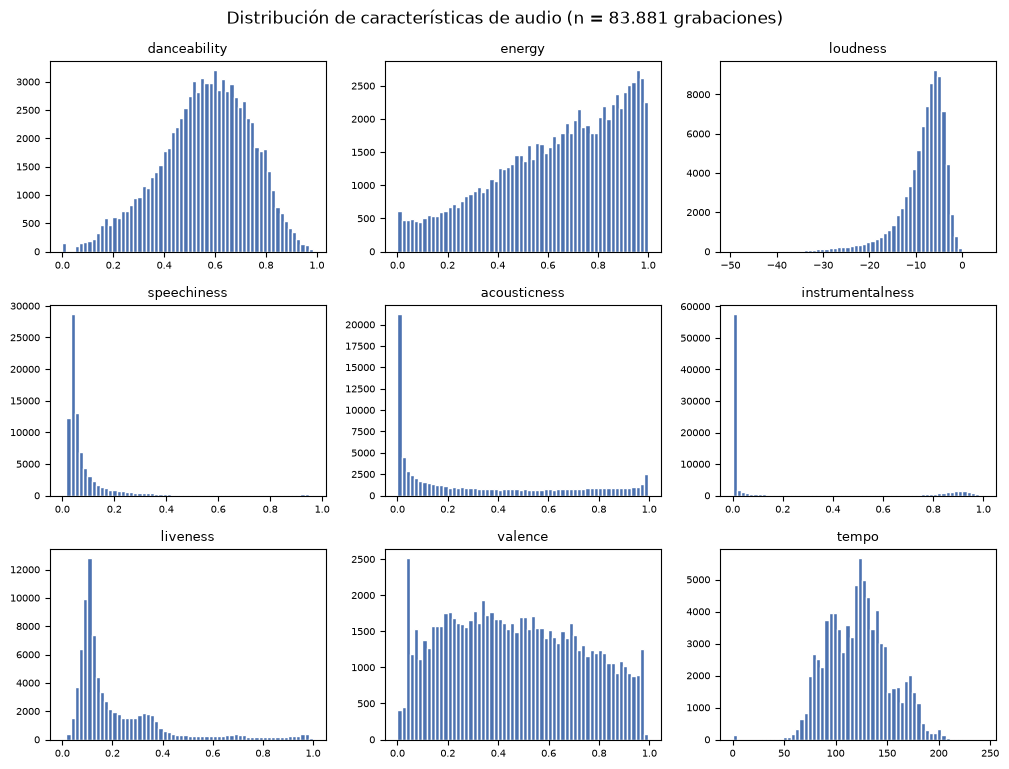

Figura guardada en reports\figures\eda_feature_histograms.png


In [3]:
path = show_and_save(
    dist.plot_feature_histograms(
        recordings,
        title="Distribución de características de audio (n = 83.881 grabaciones)",
    ),
    "eda_feature_histograms.png",
)
print("Figura guardada en", path)

**Resultado:** ver tabla y figura anteriores.

**Interpretación:** la mayoría de las variables están concentradas pero con colas
largas. `energy` es la de mayor amplitud (percentil 5–95 = 0,14–0,97; media 0,635).
`speechiness` e `instrumentalness` están fuertemente sesgadas: en `instrumentalness`
la mediana es ~0,0001 y el percentil 95 alcanza 0,914, lo que indica un gran grupo
de canciones no instrumentales y una cola claramente instrumental. `loudness` tiene
rango amplio (media −8,57 dB, p5 −19,1, p95 −3,0). `tempo` se centra en ~122 BPM
(p5–p95 = 77–175). Los mínimos en 0 de varias variables coinciden con las 145
grabaciones de análisis acústico incompleto.

**Limitación:** los histogramas describen la muestra consolidada; valores extremos
como `tempo = 0` corresponden al patrón de análisis acústico incompleto y no son
errores de recogida.

## 1.2 ¿Cómo se distribuyen las duraciones extremas?

**Método:** conteo de pistas cortas (< 60 s), largas (> 10 min) y normales a nivel
de `track_id`, más histograma de duración en minutos. Los umbrales provienen de
`configs/data_rules.yaml` (§4.2 de AGENTS.md).

In [4]:
duration_categories = dist.duration_category_counts(tracks)
duration_categories

,category,count,share_of_tracks
0,normal,88419,0.985280
1,short (< 60 s),771,0.008591
2,long (> 10 min),550,0.006129


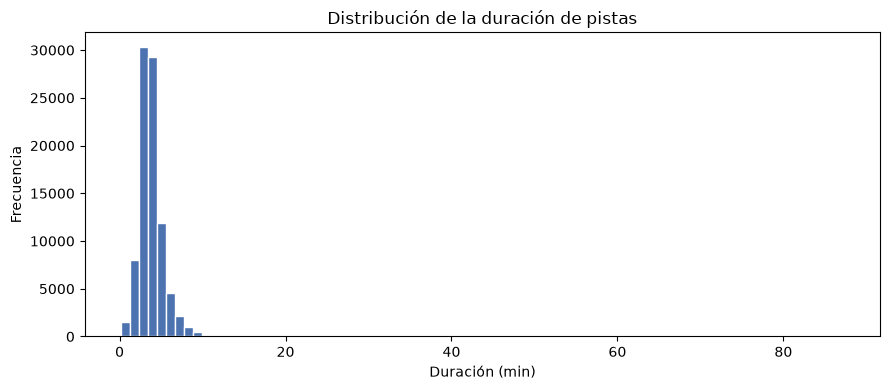

Figura guardada en reports\figures\eda_duration_histogram.png


In [5]:
path = show_and_save(
    dist.plot_duration_histogram(tracks),
    "eda_duration_histogram.png",
)
print("Figura guardada en", path)

**Resultado:** tabla y figura anteriores.

**Interpretación:** la inmensa mayoría de las pistas (98,5 %) tiene duración
normal; las cortas (< 60 s) son 771 (0,86 %) y las largas (> 10 min) 550 (0,61 %).
El histograma concentra la masa entre ~2 y ~6 minutos, con una cola que se
prolonga hasta más de 30 minutos. Estos extremos se conservan en el catálogo y
solo pueden filtrarse opcionalmente en la aplicación.

**Limitación:** la duración no es un error en sí misma; estas pistas se conservan
y solo pueden filtrarse opcionalmente en la aplicación.

## 1.3 ¿Qué diferencias descriptivas existen entre explícitas y no explícitas?

**Método:** media de cada característica de audio agrupando por `explicit` a nivel
de `track_id` (`dist.explicit_profiles`).

In [6]:
explicit = dist.explicit_profiles(tracks)
explicit

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,count
non_explicit,0.555717,0.626540,-8.673483,0.076049,0.337772,0.184538,0.214503,0.469693,122.09570,82036
explicit,0.630846,0.718776,-6.640948,0.208760,0.227260,0.054974,0.243254,0.467150,121.65812,7704


**Resultado:** tabla anterior.

**Interpretación:** hay 7.704 pistas explícitas frente a 82.036 no explícitas.
Las explícitas presentan medias mayores en `danceability` (0,631 vs 0,556),
`energy` (0,719 vs 0,627), `speechiness` (0,209 vs 0,076) y volumen más alto
(−6,64 vs −8,67 dB), y menores en `acousticness` (0,227 vs 0,338) e
`instrumentalness` (0,055 vs 0,185). `valence` y `tempo` apenas difieren.

**Limitación:** comparación descriptiva de la muestra; `explicit` no participa en
la distancia acústica del recomendador.

## 1.4 ¿Dónde aparecen anomalías?

**Método:** conteo de grabaciones con `audio_analysis_incomplete = True` por género
(`dist.incomplete_audio_by_genre`) y totales globales.

In [7]:
total_incomplete = int(recordings["audio_analysis_incomplete"].sum())
total_recordings = len(recordings)
print(
    f"Grabaciones con audio incompleto: {total_incomplete} / {total_recordings} "
    f"({total_incomplete / total_recordings:.2%})"
)

by_genre = dist.incomplete_audio_by_genre(recordings, recording_genres)
by_genre.head(15)

Grabaciones con audio incompleto: 145 / 83881 (0.17%)


,total,incomplete,share_incomplete
track_genre,,,
sleep,948,126,0.132911
iranian,973,4,0.004111
guitar,986,4,0.004057
ambient,962,3,0.003119
world-music,986,3,0.003043
opera,961,2,0.002081
jazz,513,1,0.001949
romance,888,1,0.001126
show-tunes,959,1,0.001043


**Resultado:** total y tabla anterior (se muestran los 15 géneros con más
casos).

**Interpretación:** solo 145 grabaciones (0,17 % del catálogo) presentan análisis
acústico incompleto, pero están muy concentradas: `sleep` acumula 126 de los 145
casos (≈ 87 %) y un 13,3 % de sus grabaciones es incompleto. El resto se reparte
en pequeñas cantidades (`iranian`, `guitar`, `ambient`, `world-music`, `opera`,
`jazz`, `romance`, `show-tunes`).

**Limitación:** el patrón de análisis incompleto (§4.1) se conserva en datos
procesados y se excluye de recomendadores y del baseline de clasificación.

# 2. Correlaciones y redundancia

## 2.1 ¿Qué correlaciones existen?

**Método:** matriz de correlación de Pearson entre las 9 características del
recomendador (`corr.feature_correlation`) y heatmap exportado a
`reports/figures/eda_correlation_heatmap.png`.

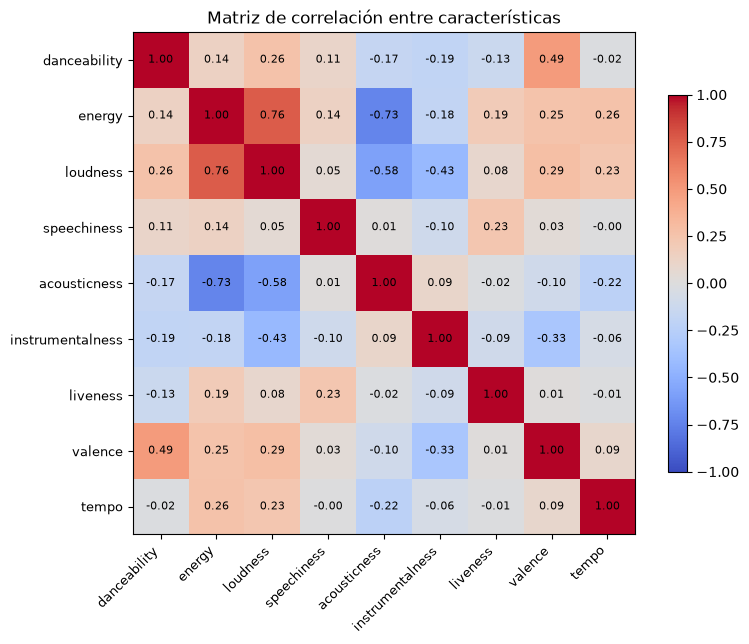

Figura guardada en reports\figures\eda_correlation_heatmap.png


In [8]:
corr_matrix = corr.feature_correlation(recordings)
path = show_and_save(
    corr.plot_correlation_heatmap(corr_matrix),
    "eda_correlation_heatmap.png",
)
print("Figura guardada en", path)

**Resultado:** heatmap anterior.

**Interpretación:** la matriz revela dos asociaciones lineales relevantes:
`energy`–`loudness` (+0,76) y `energy`–`acousticness` (−0,73). El resto de pares
queda por debajo de |0,6|. Ninguna correlación es casi perfecta, por lo que las
variables conservan información propia.

**Limitación:** Pearson mide asociación lineal y es sensible a valores atípicos
como el patrón de audio incompleto.

## 2.2 ¿Qué variables son redundantes para distancia?

**Método:** pares con |correlación| ≥ 0,6 (`corr.high_correlation_pairs`) y
diagramas de dispersión de los pares relevantes (energía–volumen y
energía–acústica).

In [9]:
high = corr.high_correlation_pairs(corr_matrix, threshold=0.6)
high

,feature_a,feature_b,correlation
0,energy,loudness,0.760742
1,energy,acousticness,-0.731966


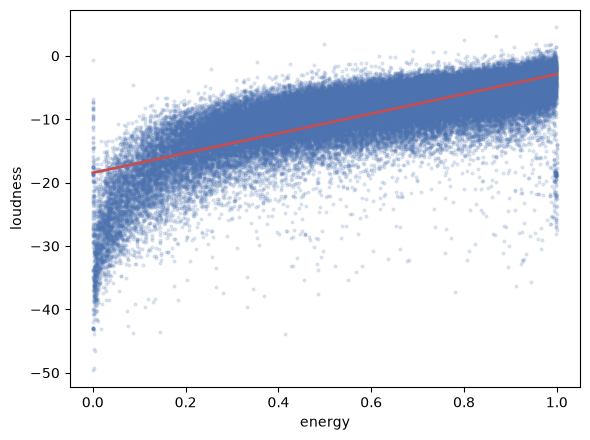

Figura guardada en reports\figures\eda_scatter_energy_loudness.png


In [10]:
path = show_and_save(
    corr.plot_pairwise_relationship(recordings, "energy", "loudness"),
    "eda_scatter_energy_loudness.png",
)
print("Figura guardada en", path)

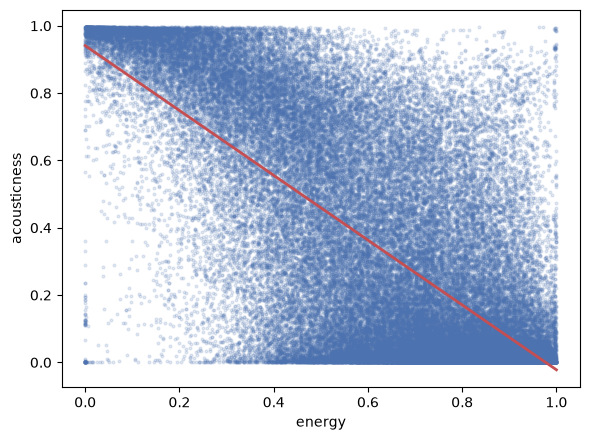

Figura guardada en reports\figures\eda_scatter_energy_acousticness.png


In [11]:
path = show_and_save(
    corr.plot_pairwise_relationship(recordings, "energy", "acousticness"),
    "eda_scatter_energy_acousticness.png",
)
print("Figura guardada en", path)

**Resultado:** tabla de pares y figuras anteriores.

**Interpretación:** solo dos pares superan |0,6| en valor absoluto: `energy`–
`loudness` (0,76) y `energy`–`acousticness` (−0,73). Los diagramas de dispersión
muestran tendencias claras pero con dispersión importante; en `energy`–`loudness`
se aprecia además el cúmulo de grabaciones con audio incompleto en el extremo
bajo. `energy` es, por tanto, la variable más solapada con otras dos, pero la
redundancia no es total.

**Limitación:** una alta correlación no implica redundancia inútil para todas las
distancias; el impacto debe medirse con experimentos de recomendación (§30 de
AGENTS.md), no decidirse solo con EDA.

## 2.3 ¿Cómo cambian las estadísticas al consolidar grabaciones?

**Método:** comparación de media y desviación de cada característica entre el nivel
`track_id` (`tracks`) y el nivel `recording_group_id` (`recordings`) mediante
`dist.consolidation_comparison`.

In [12]:
consolidation = dist.consolidation_comparison(tracks, recordings)
consolidation

,mean_tracks,std_tracks,mean_recordings,std_recordings,mean_delta
danceability,0.562166,0.176692,0.559838,0.177109,-0.002328
energy,0.634458,0.256606,0.635408,0.258108,0.000950
loudness,-8.498994,5.221518,-8.569272,5.274471,-0.070278
speechiness,0.087442,0.113278,0.088468,0.115535,0.001025
acousticness,0.328285,0.338321,0.329090,0.339608,0.000805
instrumentalness,0.173415,0.323849,0.181588,0.329395,0.008173
liveness,0.216971,0.194885,0.219133,0.197404,0.002162
valence,0.469474,0.262864,0.465203,0.263269,-0.004271
tempo,122.058134,30.117651,122.159907,30.071065,0.101773


**Resultado:** tabla anterior (las columnas `mean_delta` muestran la
diferencia al consolidar).

**Interpretación:** la consolidación de `track_id` a `recording_group_id` apenas
desplaza las medias: el mayor cambio relativo está en `loudness` (−0,07 dB) y
`instrumentalness` (+0,008); en el resto los deltas son < 0,005. Las desviaciones
también permanecen casi idénticas. La selección del track representativo por
popularidad no introduce un sesgo relevante en las estadísticas agregadas.

**Limitación:** `recordings` usa el track representativo por grupo (§9.4), por lo
que la comparación refleja la regla de selección, no una media de todas las
versiones.

# 3. Géneros y solapamientos

## 3.1 ¿Qué géneros comparten canciones?

**Método:** estadísticas de etiquetado por grabación (`go.multi_label_stats`) y
matriz de co-ocurrencia `género × género` con el número de grabaciones que comparten
ambas etiquetas (`go.cooccurrence_matrix`).

In [13]:
multi_label = go.multi_label_stats(recording_genres)
multi_label

,metric,value
0,total_recordings,83881.000
1,single_label,69943.000
2,multi_label,13938.000
3,max_labels,9.000
4,mean_labels,1.234


In [14]:
cooc = go.cooccurrence_matrix(recording_genres)
print("Matriz de co-ocurrencia:", cooc.shape)
cooc.head(5)

Matriz de co-ocurrencia: (114, 114)


track_genre,acoustic,afrobeat,alt-rock,alternative,ambient,anime,black-metal,bluegrass,blues,brazil,breakbeat,british,cantopop,chicago-house,children,chill,classical,club,comedy,country,...,sad,salsa,samba,sertanejo,show-tunes,singer-songwriter,ska,sleep,songwriter,soul,spanish,study,swedish,synth-pop,tango,techno,trance,trip-hop,turkish,world-music
track_genre,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
acoustic,959,0,0,0,0,0,0,0,14,0,0,5,0,0,0,9,0,0,0,0,...,0,0,0,0,0,12,0,0,12,0,0,0,0,0,0,0,0,0,0,0
afrobeat,0,987,0,0,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,...,0,0,5,0,0,0,3,0,0,0,0,0,0,0,0,0,0,2,0,0
alt-rock,0,0,837,454,0,2,0,0,32,51,0,3,0,0,0,0,0,0,0,2,...,0,0,0,0,0,2,51,0,2,2,5,0,2,0,0,0,0,0,13,22
alternative,0,0,454,702,0,2,0,0,16,6,1,1,0,0,0,3,0,0,0,3,...,0,0,0,0,0,3,28,0,3,16,5,0,3,2,0,0,0,4,2,14
ambient,0,0,0,0,962,2,1,0,0,0,0,15,0,0,0,3,40,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,6,0,11,0,52


**Resultado:** tabla de etiquetado y vista parcial de la matriz.

**Interpretación:** 69.943 grabaciones (83,4 %) tienen una sola etiqueta y 13.938
(16,6 %) son multigénero; la media es 1,234 etiquetas por grabación y el máximo 9.
La matriz de co-ocurrencia 114 × 114 es muy dispersa: la mayoría de pares de
géneros no comparten grabaciones.

**Limitación:** la matriz es simétrica y su diagonal contiene las grabaciones por
género; el calor de co-ocurrencia no implica similitud acústica.

## 3.2 ¿Qué etiquetas presentan solapamiento total o elevado?

**Método:** pares de géneros con más grabaciones compartidas
(`go.top_overlap_pairs`) y detección de solapamiento total, donde todo el género
menor co-ocurre con el mayor (`go.full_overlap_pairs`).

In [15]:
top_pairs = go.top_overlap_pairs(cooc, top_n=20)
top_pairs

,genre_a,genre_b,shared_recordings
0,singer-songwriter,songwriter,816
1,dub,dubstep,696
2,punk,punk-rock,568
3,indie,indie-pop,479
4,latino,reggaeton,459
5,reggae,reggaeton,454
6,alt-rock,alternative,454
7,edm,house,427
8,latino,reggae,343
9,j-pop,j-rock,327


In [16]:
counts = go.genre_recording_counts(recording_genres)
full = go.full_overlap_pairs(cooc, counts)
print("Pares con solapamiento total:", len(full))
full

Pares con solapamiento total: 1


,genre_a,genre_b,shared_recordings,cap_recordings
0,singer-songwriter,songwriter,816,816


**Resultado:** tablas anteriores.

**Interpretación:** los pares con más grabaciones compartidas reflejan familias de
géneros afines: `singer-songwriter`/`songwriter` (816), `dub`/`dubstep` (696),
`punk`/`punk-rock` (568), `indie`/`indie-pop` (479), `latino`/`reggaeton` (459) y
`alt-rock`/`alternative` (454). Existe **un único par con solapamiento total**:
`singer-songwriter`/`songwriter`, donde las 816 grabaciones del género menor
(`songwriter`) también tienen la otra etiqueta. Para el clasificador esto implica
separabilidad nula entre ambas clases y confusión esperada entre géneros afines.

**Limitación:** el solapamiento total de etiquetas degrada la separabilidad de esas
clases en el clasificador multietiqueta; debe documentarse, no corregirse
automáticamente (§5.4 de AGENTS.md).

## 3.3 ¿Qué géneros tienen perfiles acústicos similares?

**Método:** perfil medio por género de las 9 características (`go.genre_acoustic_profiles`)
y pares más similares por coseno sobre perfiles escalados (`go.similar_genre_profiles`).

In [17]:
profiles = go.genre_acoustic_profiles(recordings, recording_genres)
print("Perfiles por género:", profiles.shape)
profiles.head(8)

Perfiles por género: (114, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
track_genre,,,,,,,,,
acoustic,0.549786,0.436734,-9.461144,0.043510,0.567364,0.039974,0.153862,0.424306,118.929106
afrobeat,0.669701,0.703094,-7.759230,0.086387,0.269178,0.254159,0.181865,0.698308,119.126393
alt-rock,0.537448,0.743903,-6.310105,0.054825,0.129619,0.053909,0.217341,0.512515,123.917577
alternative,0.561704,0.716429,-6.189504,0.066984,0.147232,0.041237,0.202792,0.486711,121.691889
ambient,0.368840,0.239060,-18.553478,0.041727,0.773472,0.676669,0.128415,0.167893,111.460930
anime,0.537412,0.672381,-7.979381,0.087430,0.270543,0.266165,0.196604,0.432817,123.515696
black-metal,0.296160,0.874455,-6.536760,0.087269,0.027245,0.443707,0.241056,0.191868,128.594886
bluegrass,0.535282,0.531146,-9.922623,0.038773,0.556219,0.138447,0.227634,0.636090,126.522644


In [18]:
similar = go.similar_genre_profiles(profiles, top_n=20)
similar

,genre_a,genre_b,profile_cosine
0,singer-songwriter,songwriter,1.000000
1,latino,reggaeton,0.998624
2,edm,house,0.993791
3,punk,punk-rock,0.989837
4,acoustic,singer-songwriter,0.989140
5,acoustic,songwriter,0.989140
6,reggae,reggaeton,0.985824
7,classical,disney,0.984785
8,ambient,piano,0.984368
9,latino,reggae,0.984175


**Resultado:** perfiles y tabla de pares similares anteriores.

**Interpretación:** los pares con perfiles medios más parecidos reproducen en gran
medida los pares con más solapamiento de etiquetas: `singer-songwriter`/
`songwriter` (coseno 1,0), `latino`/`reggaeton` (0,999), `edm`/`house` (0,994),
`punk`/`punk-rock` (0,990) y `acoustic`/`singer-songwriter` (0,989). Esto indica
que algunos géneros afines son acústicamente casi indistinguibles con las 9
características disponibles, lo que previsiblemente limitará la precisión del
clasificador para esas clases.

**Limitación:** el perfil medio ignora la varianza dentro del género y la
distribución de etiquetas multigénero, por lo que es una primera aproximación.

## Conclusión del análisis exploratorio

**Resumen:** el catálogo consolidado (83.881 grabaciones) tiene distribuciones de
audio razonables y consolidadas sin sesgo relevante frente al nivel de pista.
Las anomalías de audio son escasas (0,17 %) y se concentran en `sleep`. Solo dos
pares de variables superan |0,6| de correlación (`energy`–`loudness` y `energy`–
`acousticness`), por lo que el conjunto inicial de features del recomendador no
presenta redundancia extrema. El 16,6 % de grabaciones es multigénero y existen
familias de géneros afines con solapamiento alto, incluido un par con solapamiento
total (`singer-songwriter`/`songwriter`); la clasificación multietiqueta deberá
asumir confusión esperada en esas clases. Estas observaciones se trasladan a los
experimentos de los módulos 4 y 6.

Limitaciones globales: esta es una muestra balanceada artificialmente; ningún
resultado debe presentarse como prevalencia real de Spotify ni como causalidad.